# Exploratory Data Analysis — HUPA0016P

This notebook performs an in-depth exploratory analysis of the selected patient (HUPA0016P).

The objective is to understand glucose dynamics, intervention patterns, and temporal structure before building predictive models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/HUPA0016P.csv", sep=";")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
0,2019-03-27 16:15:00,55.000000,5.866560,94.265152,0.0,0.069167,0.0,0.0
1,2019-03-27 16:20:00,55.333333,5.866560,92.787879,0.0,0.069167,0.0,0.0
2,2019-03-27 16:25:00,55.666667,5.773440,89.572464,0.0,0.069167,0.0,0.0
3,2019-03-27 16:30:00,56.000000,22.535040,112.895105,278.0,0.069167,0.0,0.0
4,2019-03-27 16:35:00,64.666667,34.454401,125.904762,491.0,0.069167,0.0,0.0


## Dataset Overview

We first inspect:

- Total duration
- Sampling frequency
- Missing values
- Basic statistical properties

Understanding data quality is essential before modeling temporal dynamics.

In [3]:
print("Start date:", df["time"].min())
print("End date:", df["time"].max())
print("Total rows:", len(df))

duration_days = (df["time"].max() - df["time"].min()).days
print("Duration (days):", duration_days)

df.describe()

Start date: 2019-03-27 16:15:00
End date: 2019-04-09 23:45:00
Total rows: 3835
Duration (days): 13


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
count,3835,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000
mean,2019-04-03 08:00:00,150.208344,8.599286,89.830006,43.735332,0.068306,0.071890,0.085984
min,2019-03-27 16:15:00,40.000000,4.656000,57.834646,0.000000,0.000000,0.000000,0.000000
25%,2019-03-31 00:07:30,85.000000,4.656000,75.432107,0.000000,0.066667,0.000000,0.000000
50%,2019-04-03 08:00:00,127.333333,5.773440,92.264463,0.000000,0.073333,0.000000,0.000000
75%,2019-04-06 15:52:30,206.595238,11.174400,102.300952,42.000000,0.073333,0.000000,0.000000
max,2019-04-09 23:45:00,362.000000,34.826880,135.268156,617.000000,0.110000,8.600000,8.000000
std,NaN,79.837161,5.491796,15.691050,94.654480,0.022617,0.575982,0.670560


In [4]:
df.isna().sum()

time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
dtype: int64

In [ ]:
# Sampling frequency: 5 min
time_diff = df["time"].diff().value_counts().head()
time_diff

time
0 days 00:05:00    3834
Name: count, dtype: int64

## Glucose Dynamics Over Time

Continuous Glucose Monitoring (CGM) provides measurements every 5 minutes.

We visualize the full time series to inspect:

- Hyperglycemic excursions
- Hypoglycemic events
- Variability patterns
- Daily structure

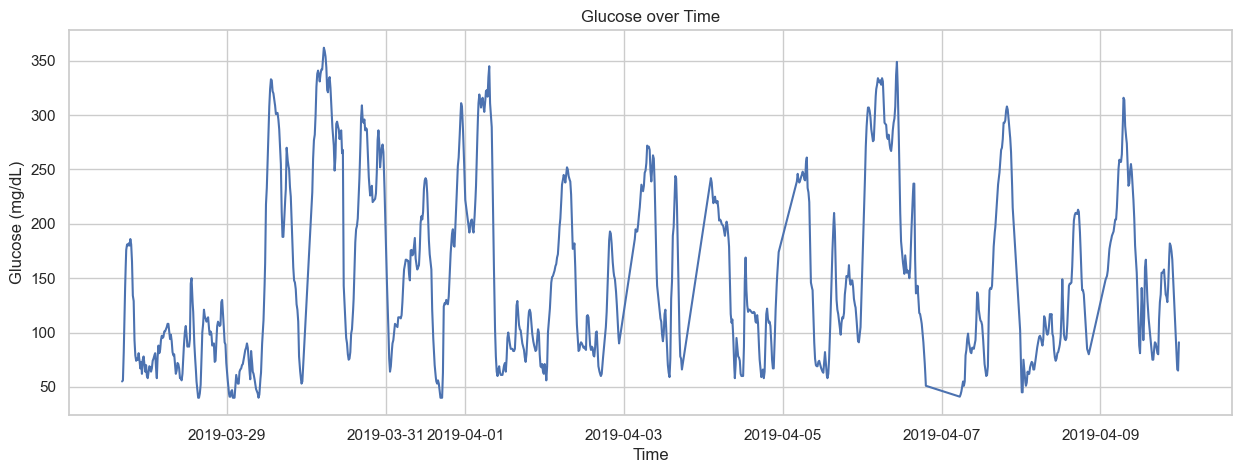

In [6]:
plt.figure(figsize=(15,5))
plt.plot(df["time"], df["glucose"])
plt.title("Glucose over Time")
plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.show()

## Meal and Insulin Events

To understand causal dynamics, we inspect:

- Carbohydrate intake events
- Bolus insulin injections
- Basal insulin profile

These interventions drive glucose fluctuations.

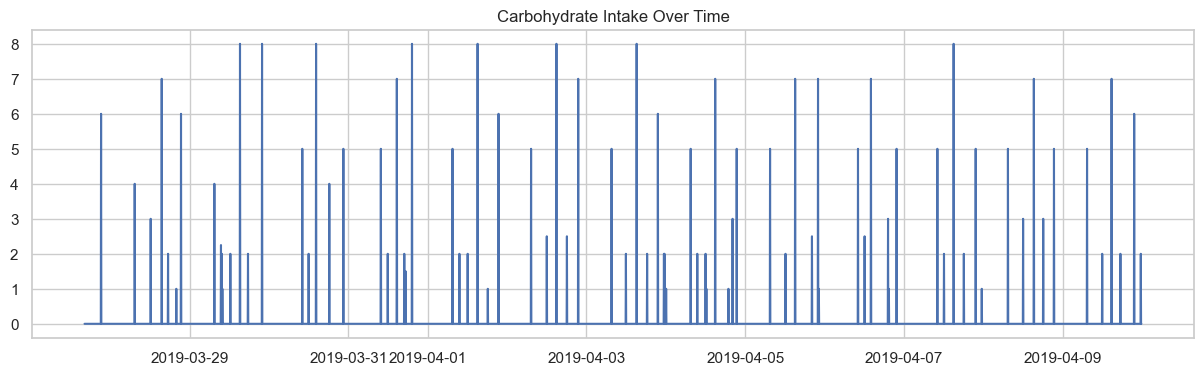

In [7]:
plt.figure(figsize=(15,4))
plt.plot(df["time"], df["carb_input"])
plt.title("Carbohydrate Intake Over Time")
plt.show()

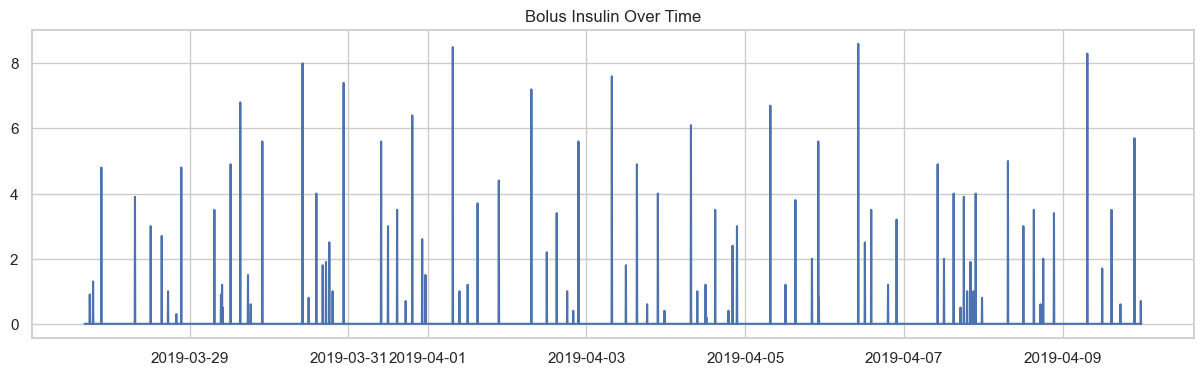

In [8]:
plt.figure(figsize=(15,4))
plt.plot(df["time"], df["bolus_volume_delivered"])
plt.title("Bolus Insulin Over Time")
plt.show()

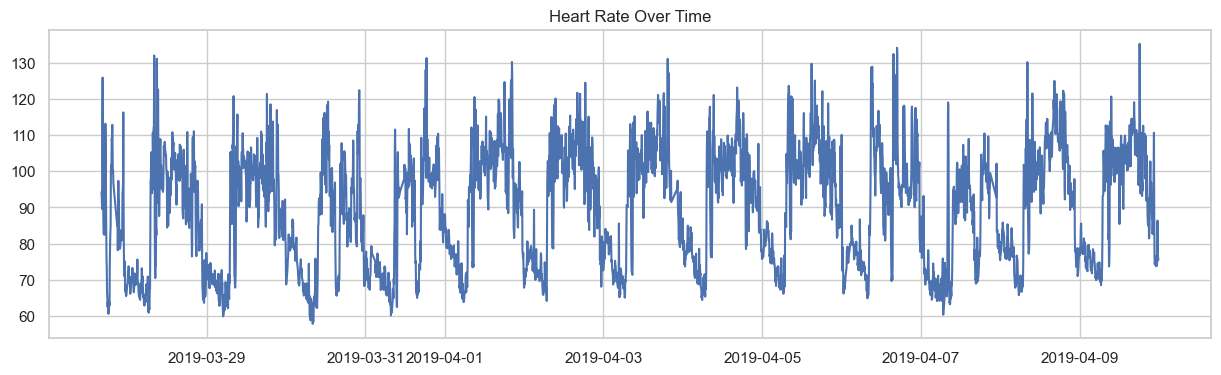

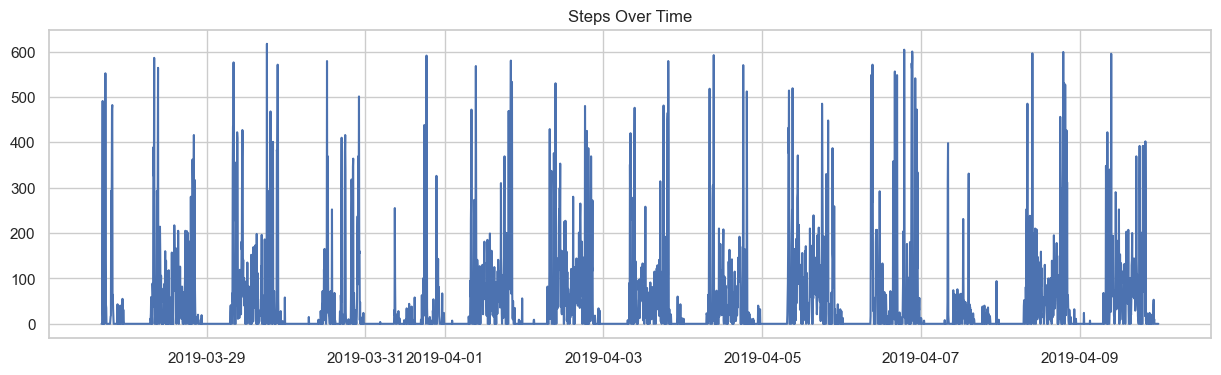

In [9]:
plt.figure(figsize=(15,4))
plt.plot(df["time"], df["heart_rate"])
plt.title("Heart Rate Over Time")
plt.show()

plt.figure(figsize=(15,4))
plt.plot(df["time"], df["steps"])
plt.title("Steps Over Time")
plt.show()

## Preliminary Observations

Key insights from the exploratory analysis:

- The dataset spans approximately 13 days with 5-minute resolution.
- Glucose shows high variability with clear postprandial spikes.
- Frequent meal and bolus events indicate active glucose management.
- Physical activity varies over time and may influence glucose dynamics.

This confirms that the selected patient provides sufficient behavioral and physiological signal for predictive modeling.

The next step will be feature engineering to capture temporal effects such as delayed meal impact and glucose trends.